<a href="https://colab.research.google.com/github/Pheonix1795/MDS_LAB/blob/main/MDS_WEEK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Load the Image
We will use `requests` to fetch the image and `PIL` to open it, then convert it to a NumPy array.

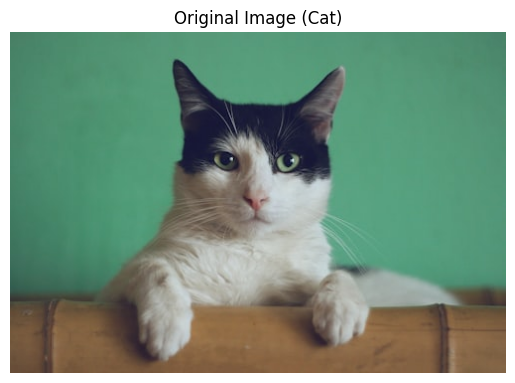

In [6]:
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Using a reliable Unsplash cat image URL to avoid 403 errors
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=500&auto=format&fit=crop"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    img_pil = Image.open(BytesIO(response.content)).convert("RGB")
    img_array = np.array(img_pil)

    plt.imshow(img_array)
    plt.title("Original Image (Cat)")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error loading image: {e}")

### 2. Crop the Image
Using NumPy slicing to take a 200x200 crop from the center.

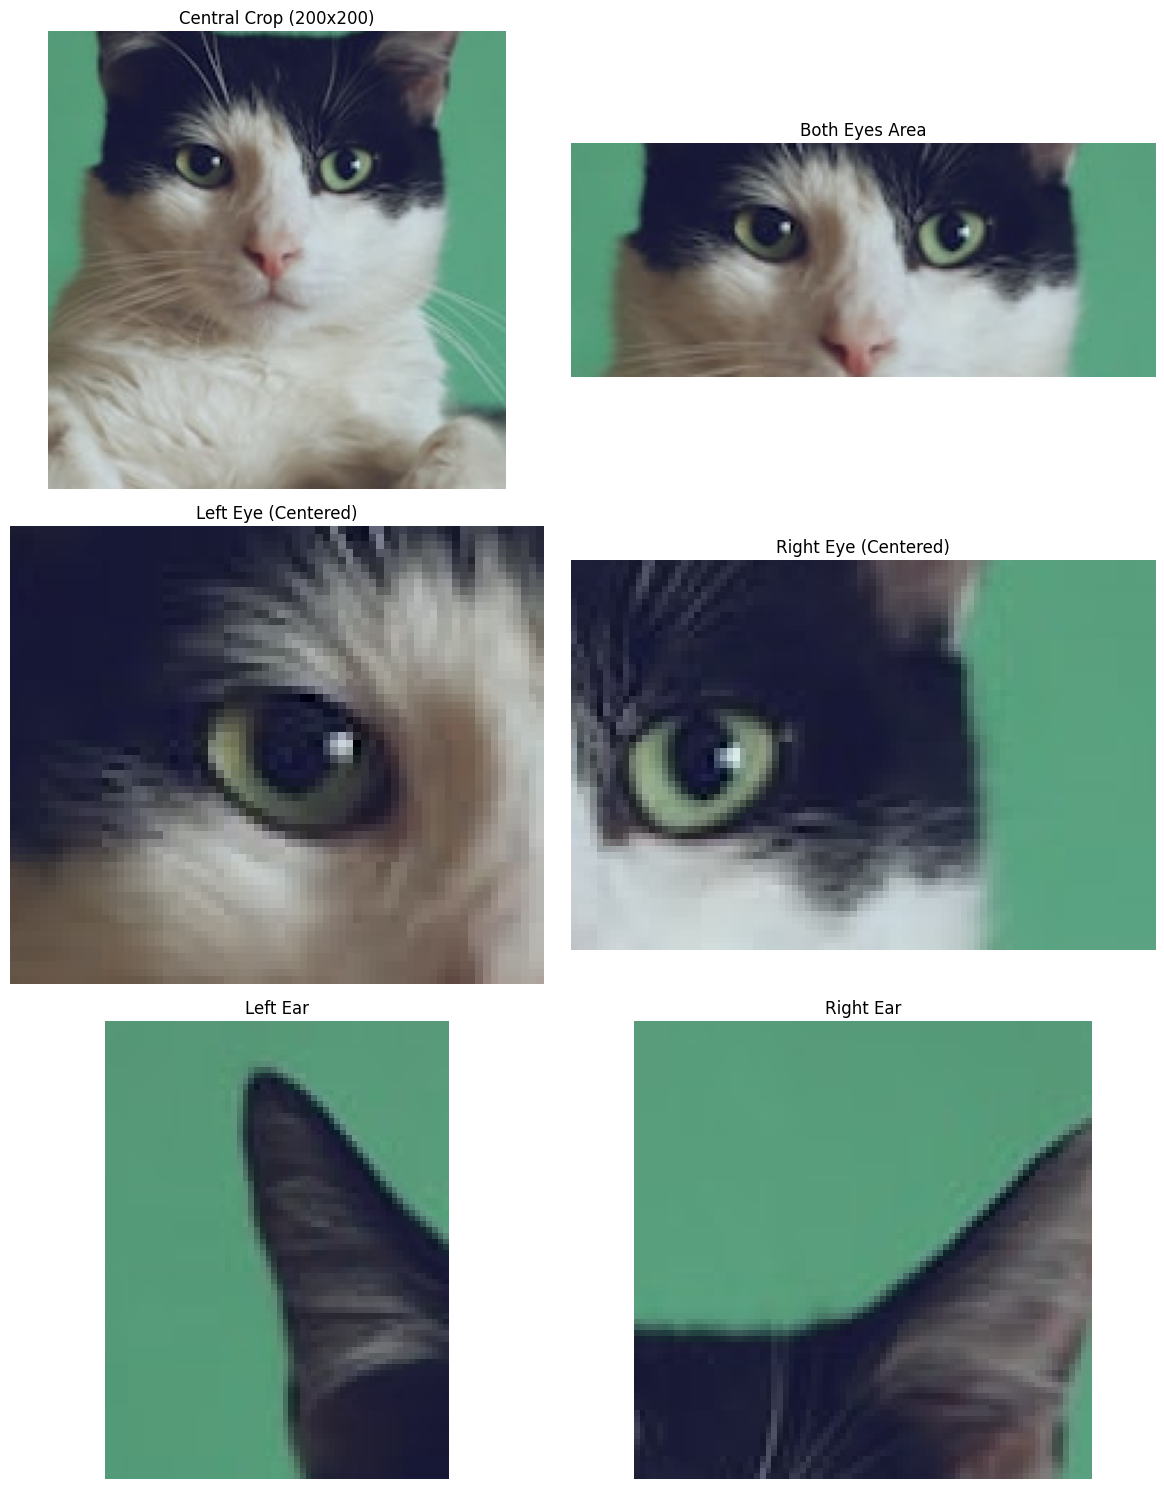

In [59]:
if 'img_array' in globals():
    h, w, _ = img_array.shape

    # 1. General Central Crop (200x200)
    start_h, start_w = h // 2 - 100, w // 2 - 100
    cropped_img = img_array[max(0, start_h) : start_h + 200, max(0, start_w) : start_w + 200]

    # 2. Crop focusing on both eyes region
    eyes_crop = img_array[100:180, 150:350]

    # 3. Individual Eye Crops
    left_eye = img_array[100:160, 180:250]
    right_eye = img_array[100:160, 260:350]

    # 4. Ear Crops
    left_ear = img_array[20:100, 140:200]
    right_ear = img_array[20:100, 250:330]

    # Displaying all results in a 3x2 grid to accommodate 6 images
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))

    # Row 0
    axes[0, 0].imshow(cropped_img)
    axes[0, 0].set_title("Central Crop (200x200)")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(eyes_crop)
    axes[0, 1].set_title("Both Eyes Area")
    axes[0, 1].axis('off')

    # Row 1
    axes[1, 0].imshow(left_eye)
    axes[1, 0].set_title("Left Eye (Centered)")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(right_eye)
    axes[1, 1].set_title("Right Eye (Centered)")
    axes[1, 1].axis('off')

    # Row 2
    axes[2, 0].imshow(left_ear)
    axes[2, 0].set_title("Left Ear")
    axes[2, 0].axis('off')

    axes[2, 1].imshow(right_ear)
    axes[2, 1].set_title("Right Ear")
    axes[2, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Error: img_array not defined. Please run the loading cell first.")

### 3. Flip the Image
Using NumPy's `[::-1]` syntax to flip the image vertically.

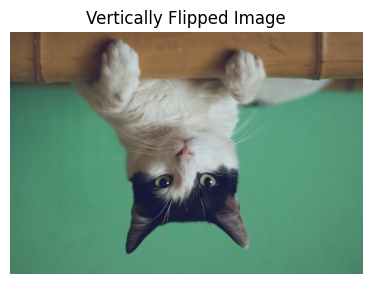

In [15]:
if 'img_array' in globals():
    # 1. NumPy indexing for vertical flip
    flipped_img = img_array[::-1, :, :]

    # 2. NumPy indexing for a crop focusing on the eyes
    # We define the eye region coordinates based on the original image dimensions
    eyes_crop = img_array[120:180, 200:350]

    # Displaying the results
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(flipped_img)
    plt.title("Vertically Flipped Image")
    plt.axis('off')

    plt.show()
else:
    print("Error: img_array not defined. Please run the loading cell first.")

### 4. CNN Model Definition
We define a simple Convolutional Neural Network using Keras to process our images.

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import cv2

# Define a simple CNN model
model = models.Sequential([
    layers.Input(shape=(200, 200, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 313632)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │     3,136,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137,226 (11.97 MB)

 Trainable params: 3,137,226 (11.97 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Applying CNN to Rotated Images
We will now rotate the cropped image by 0, 90, 180, and 270 degrees and pass each through the model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


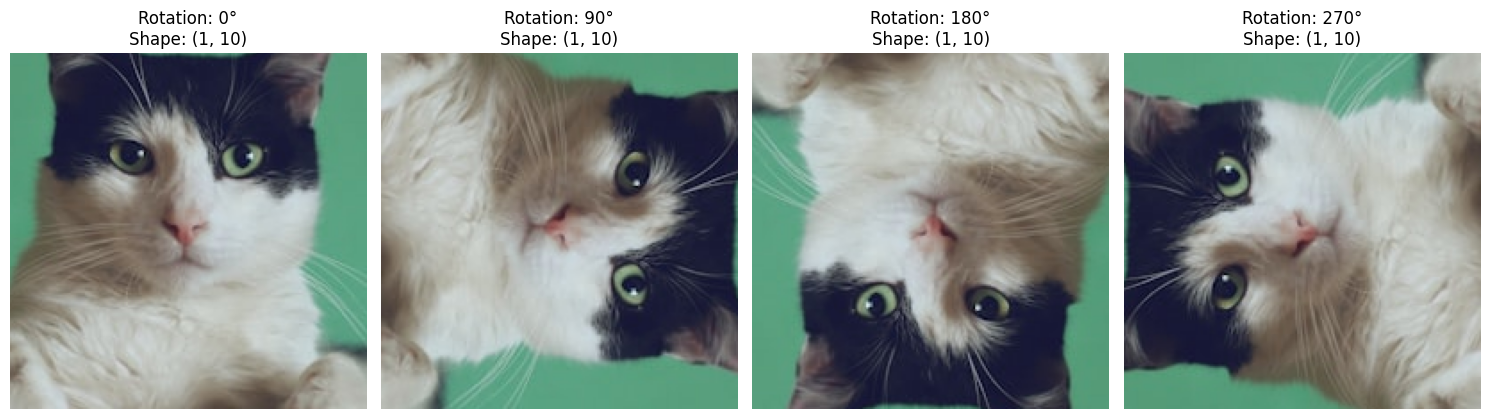

In [12]:
def process_image(image, rotation_code):
    if rotation_code is not None:
        rotated = cv2.rotate(image, rotation_code)
    else:
        rotated = image

    # Preprocess: ensure size is 200x200, normalize, and add batch dimension
    resized = cv2.resize(rotated, (200, 200))
    normalized = resized.astype('float32') / 255.0
    input_tensor = np.expand_dims(normalized, axis=0)

    # Predict
    prediction = model.predict(input_tensor)
    return rotated, prediction

rotations = [
    (None, "0°"),
    (cv2.ROTATE_90_CLOCKWISE, "90°"),
    (cv2.ROTATE_180, "180°"),
    (cv2.ROTATE_90_COUNTERCLOCKWISE, "270°")
]

plt.figure(figsize=(15, 5))
for i, (code, label) in enumerate(rotations):
    rot_img, pred = process_image(cropped_img, code)
    plt.subplot(1, 4, i+1)
    plt.imshow(rot_img)
    plt.title(f"Rotation: {label}\nShape: {pred.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Section 2: Data Analysis and Statistical Processing
In this section, we transition from image processing to structured data analysis using the California Housing dataset.

In [60]:
import pandas as pd

# 1. Import a CSV file
# Using the standard sample data provided in every Colab environment
file_path = '/content/sample_data/california_housing_train.csv'
df = pd.read_csv(file_path)

print("Dataset successfully loaded!")
print(f"Dimensions: {df.shape}")
df.head()

Dataset successfully loaded!
Dimensions: (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


## 2.1 Summary Statistics
Calculating measures of central tendency, dispersion, and overall distribution for the housing features.

In [61]:
# 2. Statistical Operations
stats_summary = {
    'Mean House Value': df['median_house_value'].mean(),
    'Median Age': df['housing_median_age'].median(),
    'Standard Deviation (Rooms)': df['total_rooms'].std(),
    'Total Population Sum': df['population'].sum()
}

for stat, value in stats_summary.items():
    print(f"{stat}: {value:,.2f}")

# Detailed description for all numeric columns
df.describe()

Mean House Value: 207,300.91
Median Age: 29.00
Standard Deviation (Rooms): 2,179.95
Total Population Sum: 24,302,757.00


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2.2 Comparison and Filtering
Applying boolean logic and thresholds to identify specific segments within the dataset, such as high-income areas.

In [62]:
# 3. Comparison Operations
# Filtering: Rows where median income is greater than 10
high_income_df = df[df['median_income'] > 10]

# Comparison: Find rows where bedrooms are more than 10% of total rooms
high_bedroom_ratio = df[df['total_bedrooms'] > (df['total_rooms'] * 0.1)]

print(f"Number of high income areas: {len(high_income_df)}")
print(f"Number of areas with high bedroom-to-room ratio: {len(high_bedroom_ratio)}")

# Boolean comparison between columns
df['more_rooms_than_pop'] = df['total_rooms'] > df['population']
print(f"\nSample of room vs population comparison:\n{df[['total_rooms', 'population', 'more_rooms_than_pop']].head()}")

Number of high income areas: 259
Number of areas with high bedroom-to-room ratio: 16997

Sample of room vs population comparison:
   total_rooms  population  more_rooms_than_pop
0       5612.0      1015.0                 True
1       7650.0      1129.0                 True
2        720.0       333.0                 True
3       1501.0       515.0                 True
4       1454.0       624.0                 True
